Satellite Pass Visualization
Using real API data with mock fallback

Processing Healpix ID: 891
Healpix 891 -> Azimuth: 154.69°, Elevation: 24.62°
Horizontal -> Equatorial: RA 102.946°, Dec -67.010°

[Processing] Healpix ID 891
[Field Center] RA 102.946°, Dec -67.010°
[API Request] JD: 2460602.371181, RA: 102.946°, Dec: -67.010°
[API Response] Status: 200
[API Success] Found 7 satellites
[Data] Processing 7 satellites


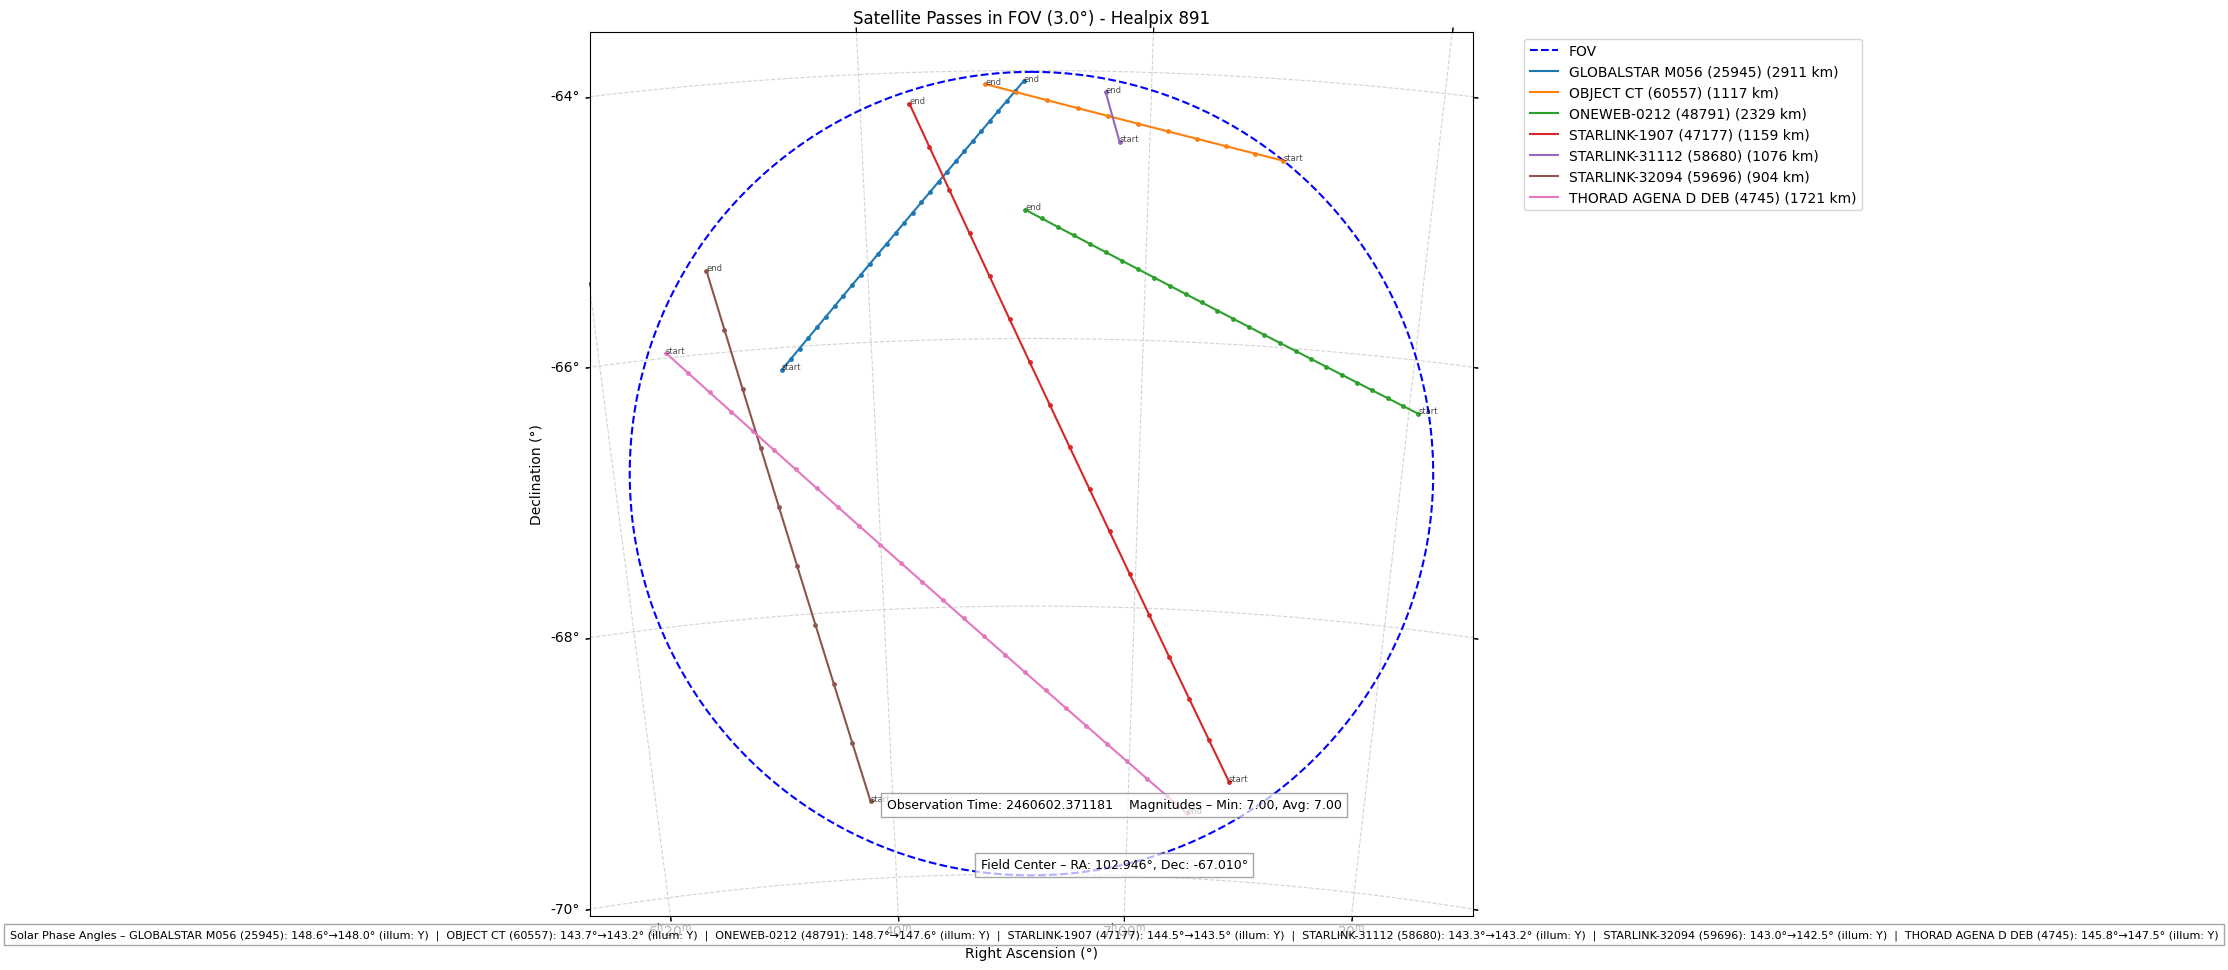


--- Illumination Status ---
GLOBALSTAR M056 (25945): Illuminated
OBJECT CT (60557): Illuminated
ONEWEB-0212 (48791): Illuminated
STARLINK-1907 (47177): Illuminated
STARLINK-31112 (58680): Illuminated
STARLINK-32094 (59696): Illuminated
THORAD AGENA D DEB (4745): Illuminated

Processing Healpix ID: 963
Healpix 963 -> Azimuth: -163.12°, Elevation: 22.02°
Horizontal -> Equatorial: RA 255.220°, Dec -73.219°

[Processing] Healpix ID 963
[Field Center] RA 255.220°, Dec -73.219°
[API Request] JD: 2460602.368403, RA: 255.220°, Dec: -73.219°
[API Response] Status: 200
[API Success] Found 8 satellites
[Data] Processing 8 satellites


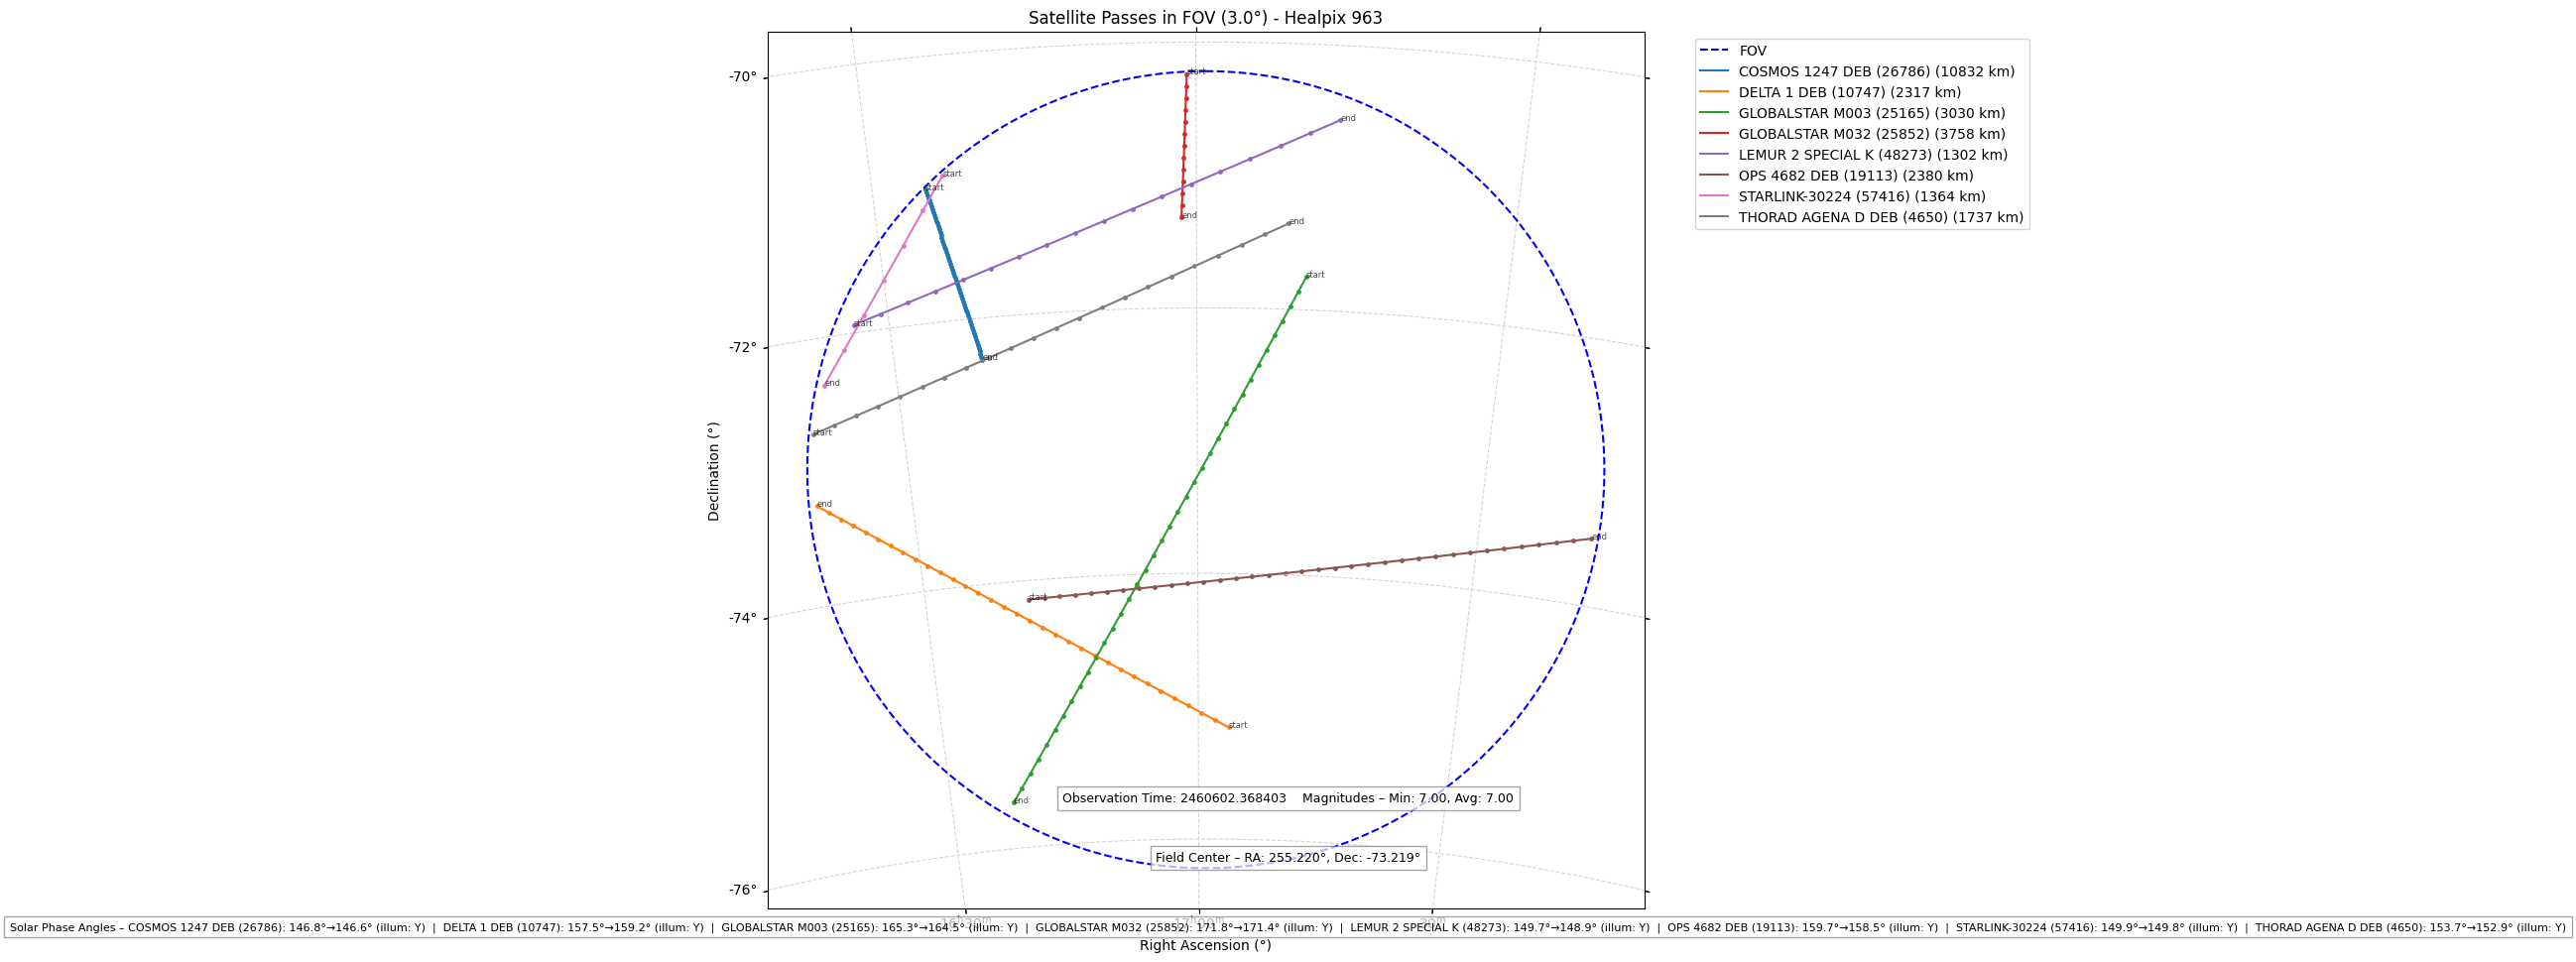


--- Illumination Status ---
COSMOS 1247 DEB (26786): Illuminated
DELTA 1 DEB (10747): Illuminated
GLOBALSTAR M003 (25165): Illuminated
GLOBALSTAR M032 (25852): Illuminated
LEMUR 2 SPECIAL K (48273): Illuminated
OPS 4682 DEB (19113): Illuminated
STARLINK-30224 (57416): Illuminated
THORAD AGENA D DEB (4650): Illuminated

Processing Healpix ID: 1025
Healpix 1025 -> Azimuth: -171.56°, Elevation: 19.47°
Horizontal -> Equatorial: RA 225.497°, Dec -77.635°

[Processing] Healpix ID 1025
[Field Center] RA 225.497°, Dec -77.635°
[API Request] JD: 2460602.364931, RA: 225.497°, Dec: -77.635°
[API Response] Status: 200
[API Success] Found 7 satellites
[Data] Processing 7 satellites


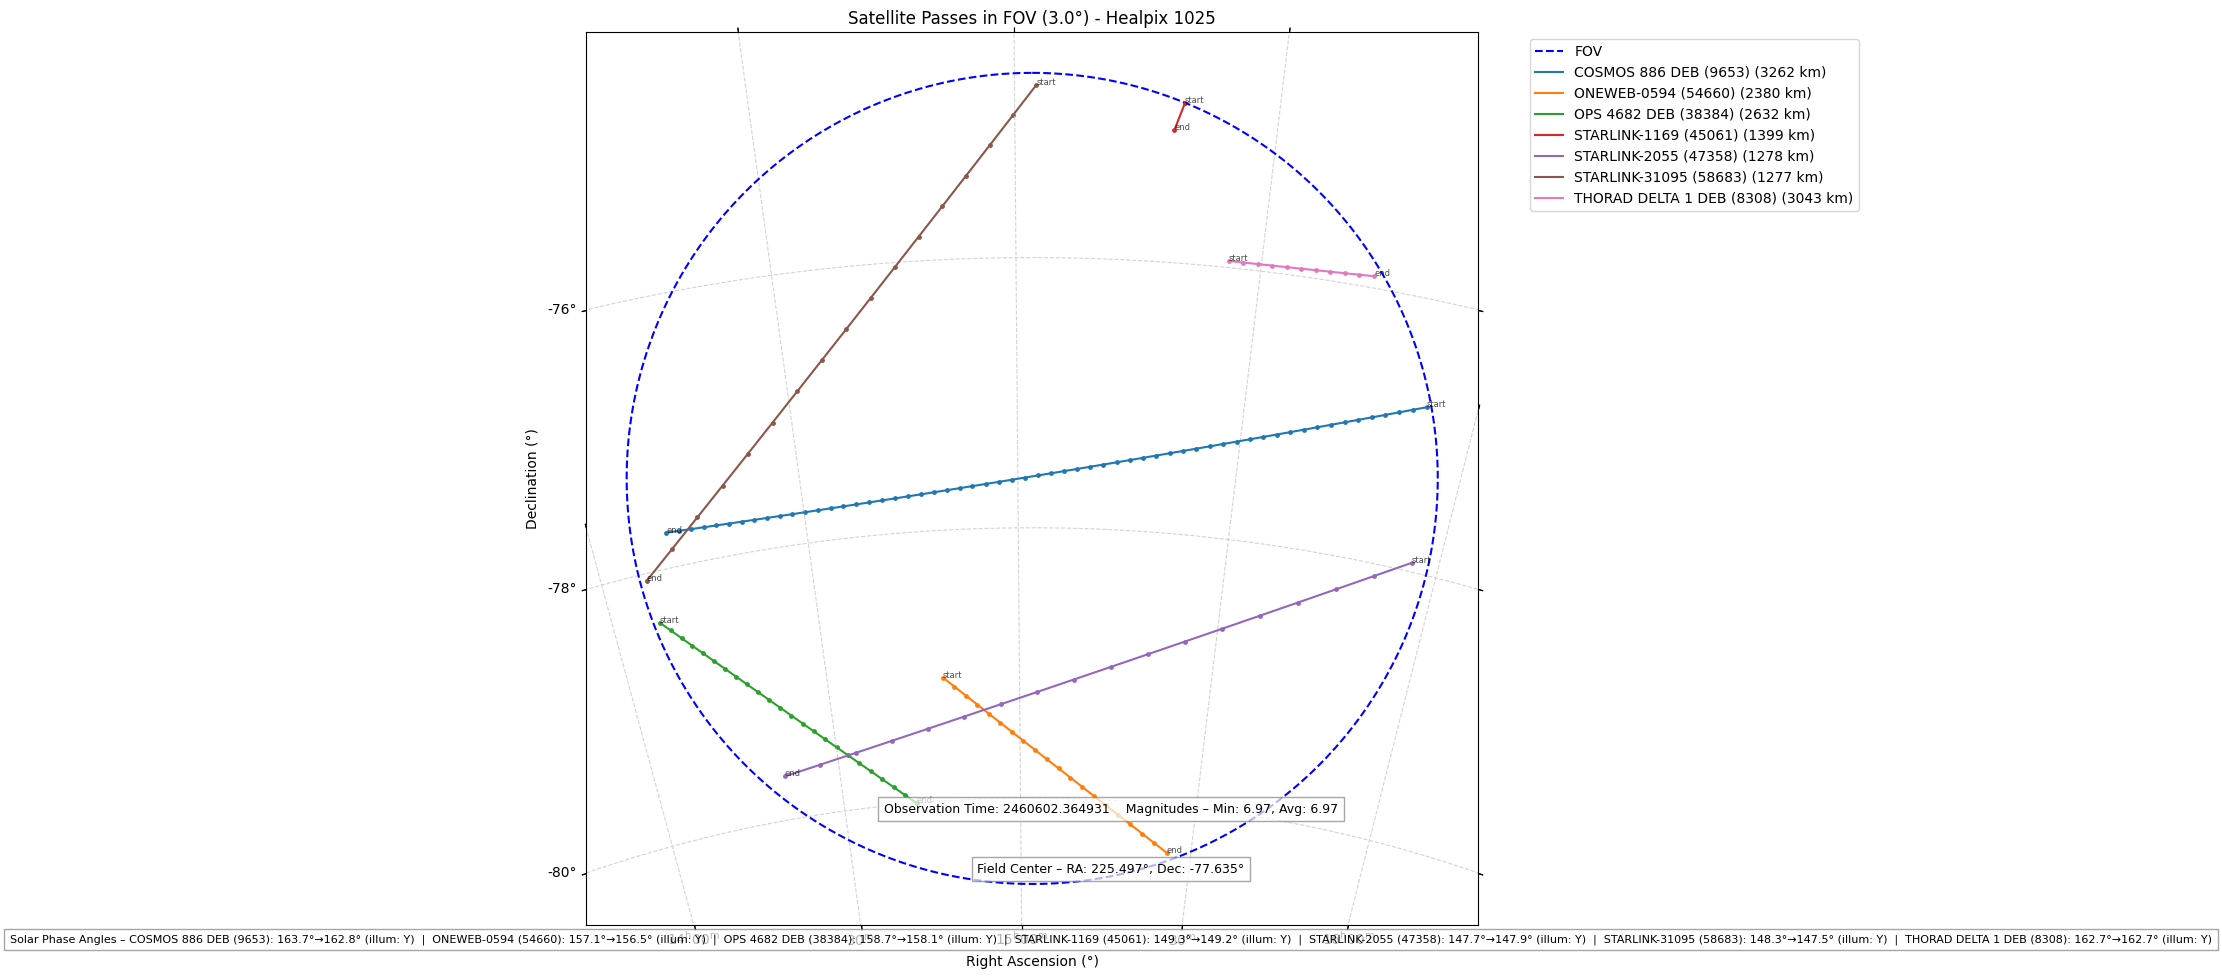


--- Illumination Status ---
COSMOS 886 DEB (9653): Illuminated
ONEWEB-0594 (54660): Illuminated
OPS 4682 DEB (38384): Illuminated
STARLINK-1169 (45061): Illuminated
STARLINK-2055 (47358): Illuminated
STARLINK-31095 (58683): Illuminated
THORAD DELTA 1 DEB (8308): Illuminated

Processing Healpix ID: 955
Healpix 955 -> Azimuth: 151.88°, Elevation: 22.02°
Horizontal -> Equatorial: RA 107.032°, Dec -63.710°

[Processing] Healpix ID 955
[Field Center] RA 107.032°, Dec -63.710°
[API Request] JD: 2460602.371875, RA: 107.032°, Dec: -63.710°
[API Response] Status: 200
[API Success] Found 7 satellites
[Data] Processing 7 satellites


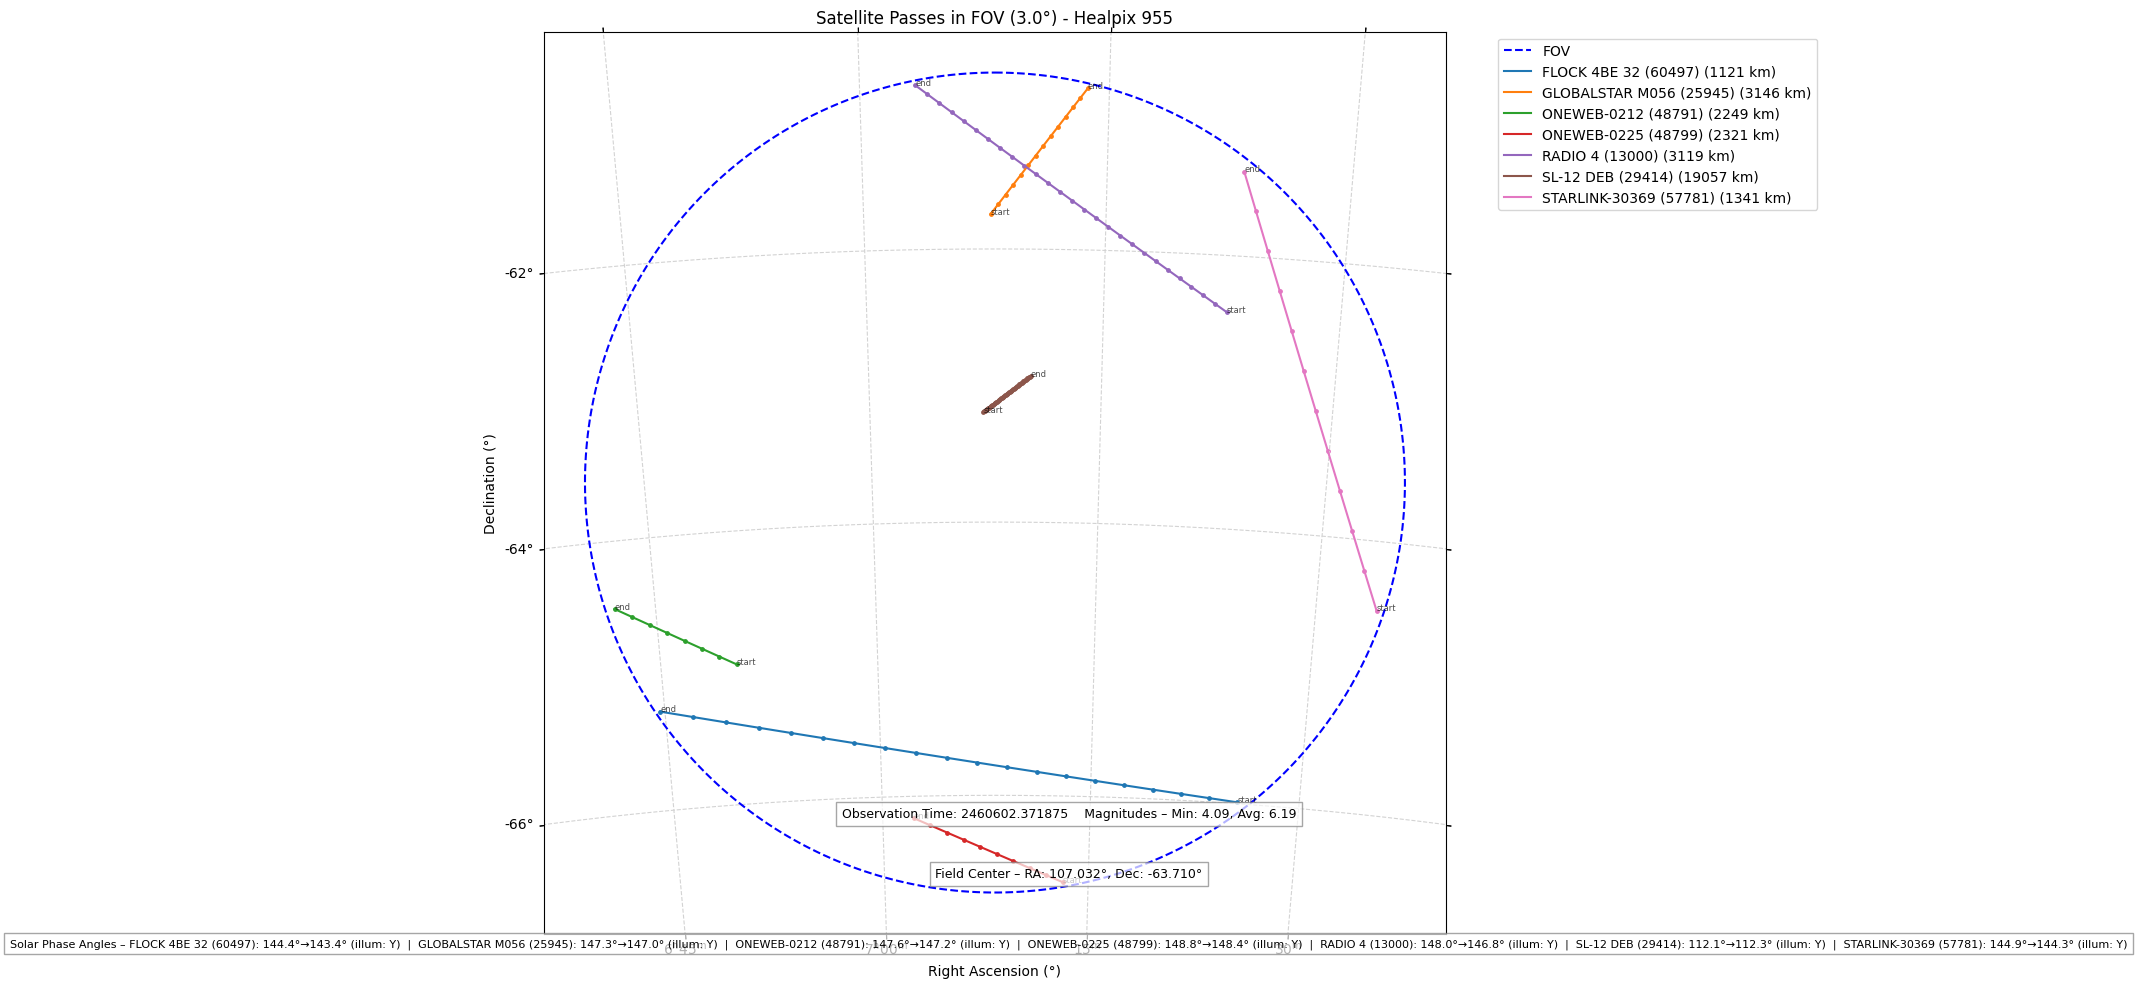


--- Illumination Status ---
FLOCK 4BE 32 (60497): Illuminated
GLOBALSTAR M056 (25945): Illuminated
ONEWEB-0212 (48791): Illuminated
ONEWEB-0225 (48799): Illuminated
RADIO 4 (13000): Illuminated
SL-12 DEB (29414): Illuminated
STARLINK-30369 (57781): Illuminated

Processing Healpix ID: 831
Healpix 831 -> Azimuth: 174.38°, Elevation: 27.28°
Horizontal -> Equatorial: RA 116.572°, Dec -84.686°

[Processing] Healpix ID 831
[Field Center] RA 116.572°, Dec -84.686°
[API Request] JD: 2460602.369792, RA: 116.572°, Dec: -84.686°
[API Response] Status: 200
[API Success] Found 4 satellites
[Data] Processing 4 satellites


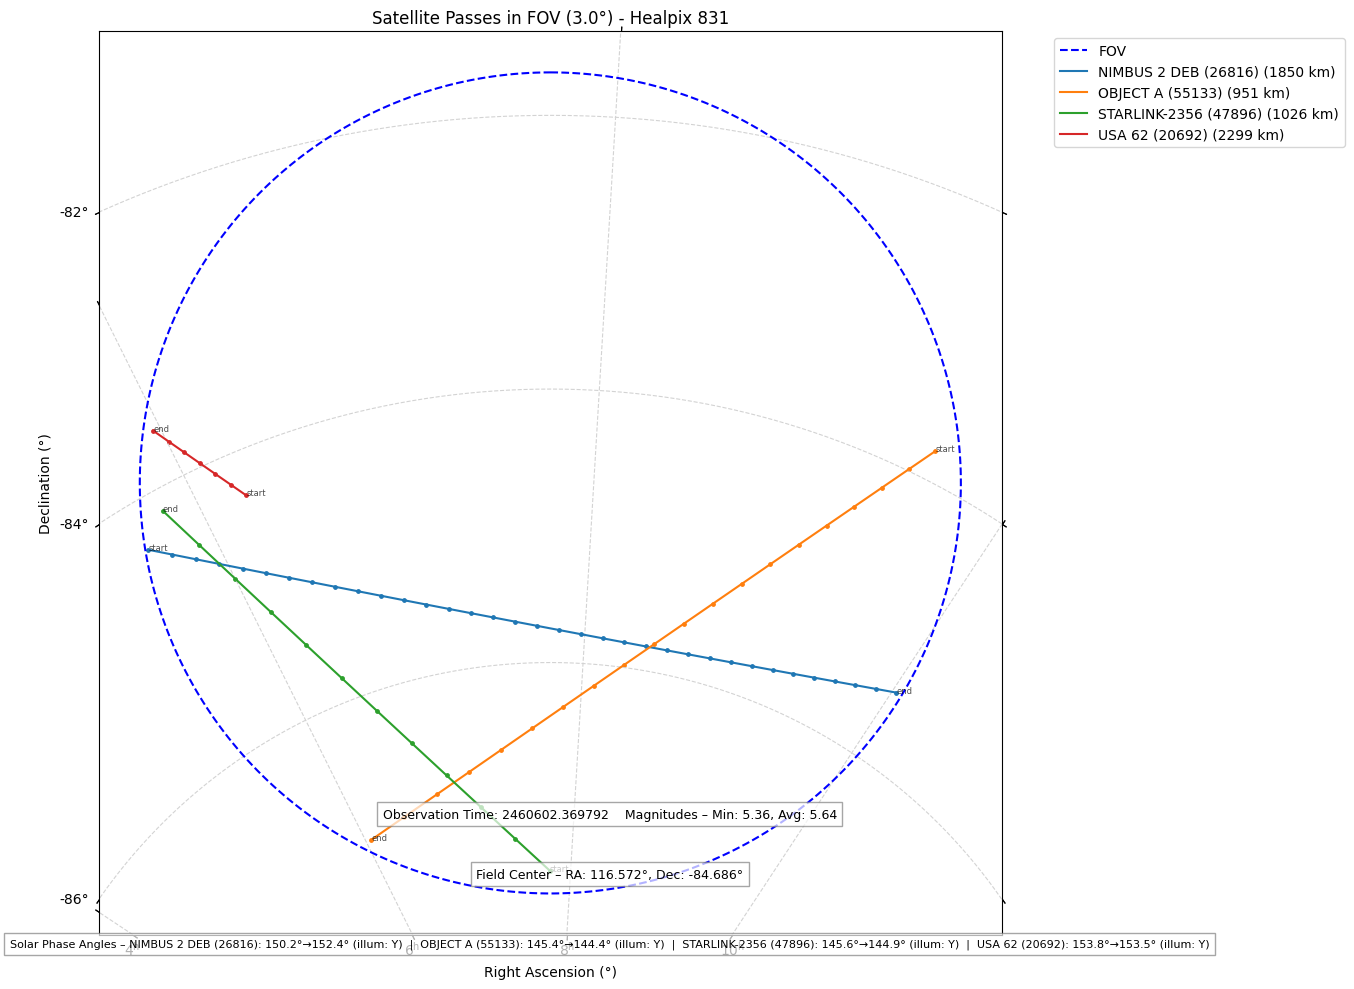


--- Illumination Status ---
NIMBUS 2 DEB (26816): Illuminated
OBJECT A (55133): Illuminated
STARLINK-2356 (47896): Illuminated
USA 62 (20692): Illuminated

Processing Healpix ID: 896
Healpix 896 -> Azimuth: -177.19°, Elevation: 24.62°
Horizontal -> Equatorial: RA 216.228°, Dec -84.811°

[Processing] Healpix ID 896
[Field Center] RA 216.228°, Dec -84.811°
[API Request] JD: 2460602.369097, RA: 216.228°, Dec: -84.811°
[API Response] Status: 200
[API Success] Found 2 satellites
[Data] Processing 2 satellites


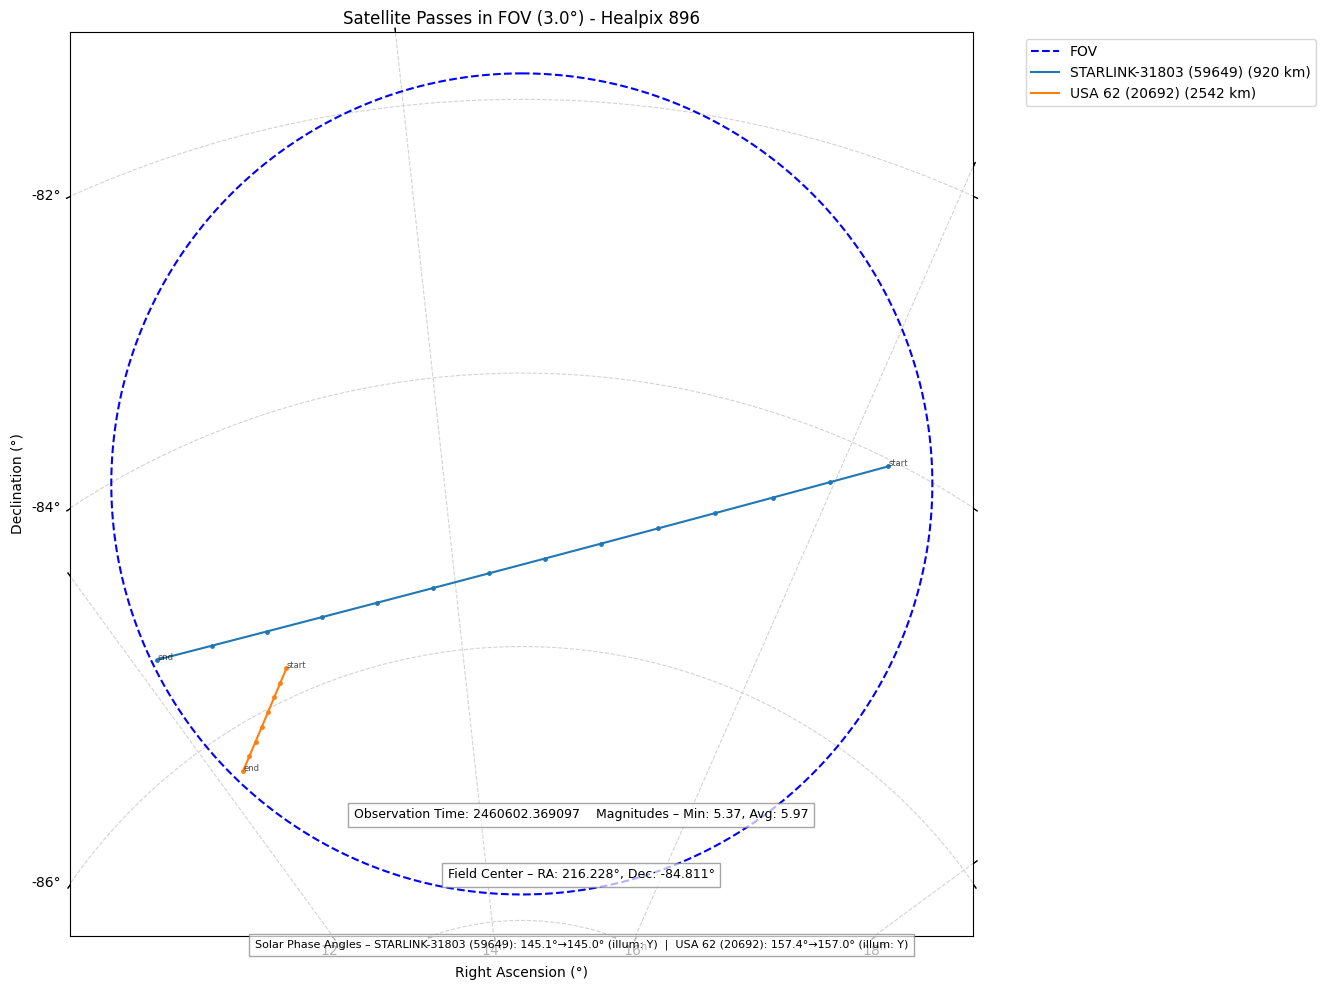


--- Illumination Status ---
STARLINK-31803 (59649): Illuminated
USA 62 (20692): Illuminated


In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, ICRS, get_sun
import astropy.units as u
from astropy.wcs import WCS
from astropy.time import Time
import requests
from skyfield.api import load, wgs84
import time
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import astropy.coordinates

# Load ephemeris and timescale
ts = load.timescale()
eph = load('de440s.bsp')
sun = eph['Sun']
earth = eph['Earth']

def create_session_with_retries():
    """Create a requests session with retry strategy"""
    session = requests.Session()
    
    retry_strategy = Retry(
        total=3,
        backoff_factor=1,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"]
    )
    
    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("http://", adapter)
    session.mount("https://", adapter)
    
    return session

def healpix_to_lonlat(healpix_id, nside=16):
    theta, phi = hp.pix2ang(nside, healpix_id, nest=False)
    lat = 90 - np.degrees(theta)
    lon = np.degrees(phi)
    lon = ((lon + 180) % 360) - 180
    return lon, lat

def horizontal_to_equatorial(latitude, longitude, elevation, azimuth_deg, elevation_obs_deg, julian_day):
    location = EarthLocation(lat=latitude*u.deg, lon=longitude*u.deg, height=elevation*u.m)
    t = Time(julian_day, format='jd')
    altaz = AltAz(az=azimuth_deg*u.deg, alt=elevation_obs_deg*u.deg, location=location, obstime=t)
    eq = altaz.transform_to(ICRS())
    return eq.ra.deg, eq.dec.deg

def get_satellite_data(jd_time, ra_c, dec_c):
    """Get satellite data using the working API parameters"""
    all_parameters = []
    
    # Define Earth location with height
    south_af = astropy.coordinates.EarthLocation(
        lat=-29.038169452952143*u.deg, 
        lon=26.402995668269295*u.deg, 
        height=1372*u.m
    )
    
    # API base URL
    url = 'https://satchecker.cps.iau.org/fov/satellite-passes/'    
    
    # API parameters for this specific Julian date
    params = {
        'latitude': -29.038169452952143, 
        'longitude': 26.402995668269295, 
        'elevation': 1372, 
        'start_time_jd': jd_time,  # Use the current Julian date
        'duration': 60, 
        'ra': ra_c, 
        'dec': dec_c, 
        'fov_radius': 3, 
        'group_by': 'satellite'
    }
    
    print(f"[API Request] JD: {jd_time:.6f}, RA: {ra_c:.3f}°, Dec: {dec_c:.3f}°")
    
    session = create_session_with_retries()
    
    try:
        resp = session.get(url, params=params, timeout=60)
        print(f"[API Response] Status: {resp.status_code}")
        
        if resp.status_code == 200:
            data = resp.json()
            satellite_count = len(data['data']['satellites'])
            print(f"[API Success] Found {satellite_count} satellites")
            return data
        else:
            print(f"[API Error] HTTP {resp.status_code}: {resp.reason}")
            print(f"[API Error] Response: {resp.text[:200]}")
            return None
            
    except requests.exceptions.RequestException as e:
        print(f"[API Error] Request failed: {e}")
        return None
    except Exception as e:
        print(f"[API Error] Unexpected error: {e}")
        return None

def create_mock_satellite_data(ra_center, dec_center, fov_radius):
    """Create mock satellite data for testing when API is down"""
    print("[Info] Using mock satellite data for demonstration")
    
    # Create some mock satellite tracks around the center
    mock_satellites = {}
    
    # Create 2-4 mock satellites with different trajectories
    for i in range(np.random.randint(2, 5)):
        sat_name = f"SAT_{i+1:03d}"
        
        # Create positions along a line through the FOV
        num_points = 10
        ra_points = np.linspace(ra_center - fov_radius/2, ra_center + fov_radius/2, num_points)
        dec_points = np.linspace(dec_center - fov_radius/2, dec_center + fov_radius/2, num_points)
        
        # Add some curvature
        dec_points = dec_points + np.sin(np.linspace(0, 2*np.pi, num_points)) * fov_radius/4
        
        positions = []
        for j in range(num_points):
            positions.append({
                'ra': float(ra_points[j]),
                'dec': float(dec_points[j]),
                'julian_date': 2460602.37 + j * 0.001,
                'range_km': 500 + i * 100 + j * 10,
                'azimuth': 180 + i * 30,
                'altitude': 30 + j * 2
            })
        
        mock_satellites[sat_name] = {'positions': positions}
    
    return {'data': {'satellites': mock_satellites}}

def plot_satellite_passes(latitude, longitude, elevation,
                         mid_obs_time_jd, duration,
                         ra_center, dec_center, fov_radius,
                         healpix_id, min_mag, avg_mag,
                         use_mock_data=False):

    print(f"\n[Processing] Healpix ID {healpix_id}")
    print(f"[Field Center] RA {ra_center:.3f}°, Dec {dec_center:.3f}°")

    # Get satellite data using the working API function
    if use_mock_data:
        data = create_mock_satellite_data(ra_center, dec_center, fov_radius)
    else:
        data = get_satellite_data(mid_obs_time_jd, ra_center, dec_center)
    
    if data is None:
        print(f"[Warning] No data available for Healpix {healpix_id}. Using mock data.")
        data = create_mock_satellite_data(ra_center, dec_center, fov_radius)
        use_mock_data = True

    # Process the satellite data
    obser_pos = wgs84.latlon(latitude, longitude)

    satellites = {
        sat_key: [
            [p['ra'], p['dec'], p['julian_date'], p['range_km'], p['azimuth'], p['altitude']]
            for p in sat_data['positions']
        ]
        for sat_key, sat_data in data['data']['satellites'].items()
    }

    print(f"[Data] Processing {len(satellites)} satellites")

    mean_ranges = {}
    phase_stats = {}
    illumination_flags = {}

    for name, lst in satellites.items():
        arr = np.array(lst)
        mean_ranges[name] = arr[:, 3].mean()

        phases = []
        illuminated_status = []

        for ra, dec, jd, rang, _, _ in arr:
            rangn = np.linalg.norm(rang)
            t = ts.ut1_jd(jd)
            sat_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, distance=rangn * u.km, frame='icrs')
            sat = sat_coord.cartesian.xyz.to(u.km).value

            topocentric = sat - obser_pos.at(t).position.km
            topocentricn = topocentric / np.linalg.norm(topocentric)

            earthp = earth.at(t).position.km
            sunp = sun.at(t).position.km
            earthsun = sunp - earthp
            earthsunn = earthsun / np.linalg.norm(earthsun)

            satsun = sat - earthsun
            satsunn = satsun / np.linalg.norm(satsun)
            phase_angle = np.rad2deg(np.arccos(np.dot(satsunn, topocentricn)))

            r_parallel = np.dot(sat, earthsunn) * earthsunn
            r_tangential = sat - r_parallel
            illuminated = not (
                np.dot(sat, earthsunn) < 0 and np.linalg.norm(r_tangential) < 6378.137
            )

            illuminated_status.append(illuminated)
            phases.append(phase_angle)

        phases = np.array(phases)
        phase_stats[name] = (phases[0], phases[-1], phases.mean())
        illumination_flags[name] = all(illuminated_status)

    # Create the plot
    wcs = WCS(naxis=2)
    wcs.wcs.crpix = [0, 0]
    wcs.wcs.crval = [ra_center, dec_center]
    wcs.wcs.cdelt = [0.1, 0.1]
    wcs.wcs.ctype = ['RA---TAN', 'DEC--TAN']

    fig = plt.figure(figsize=(12, 10))
    fig.subplots_adjust(bottom=0.25)
    ax = fig.add_subplot(1, 1, 1, projection=wcs)

    center = SkyCoord(ra=ra_center * u.deg, dec=dec_center * u.deg)
    pa = np.linspace(0, 360, 360) * u.deg
    circ = center.directional_offset_by(pa, fov_radius * u.deg)
    ax.plot(circ.ra.deg, circ.dec.deg, 'b--',
            transform=ax.get_transform('world'), label='FOV')

    for name, lst in satellites.items():
        arr = np.array(lst)
        coords = SkyCoord(ra=arr[:, 0] * u.deg, dec=arr[:, 1] * u.deg)
        label = f"{name} ({mean_ranges.get(name, 0):.0f} km)"
        ax.plot(coords.ra.deg, coords.dec.deg,
                transform=ax.get_transform('world'), label=label)
        ax.scatter(coords.ra.deg, coords.dec.deg,
                   transform=ax.get_transform('world'), s=6)

        # Add start/end labels
        s_ra, s_dec = coords.ra.deg[0], coords.dec.deg[0]
        e_ra, e_dec = coords.ra.deg[-1], coords.dec.deg[-1]
        
        ax.text(s_ra, s_dec, "start",
                transform=ax.get_transform('world'), fontsize=6, alpha=0.7)
        ax.text(e_ra, e_dec, "end",
                transform=ax.get_transform('world'), fontsize=6, alpha=0.7)

    ax.set_aspect('equal')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xlabel('Right Ascension (\u00b0)')
    ax.set_ylabel('Declination (\u00b0)')
    
    title_suffix = " (MOCK DATA)" if use_mock_data else ""
    ax.set_title(f'Satellite Passes in FOV ({fov_radius}\u00b0) - Healpix {healpix_id}{title_suffix}')
    ax.grid(color='lightgray', linestyle='--')

    # Add information text
    line1 = (
        f"Observation Time: {mid_obs_time_jd:.6f}    "
        f"Magnitudes – Min: {min_mag:.2f}, Avg: {avg_mag:.2f}"
    )
    line2 = f"Field Center – RA: {ra_center:.3f}°, Dec: {dec_center:.3f}°"
    
    if phase_stats:
        line3 = "Solar Phase Angles – " + "  |  ".join(
            f"{n}: {st:.1f}°→{en:.1f}° (illum: {'Y' if illumination_flags.get(n, False) else 'N'})"
            for n, (st, en, mn) in phase_stats.items()
        )
    else:
        line3 = "No phase angle data available"

    fig.text(0.5, 0.18, line1, ha='center', va='center', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
    fig.text(0.5, 0.12, line2, ha='center', va='center', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
    fig.text(0.5, 0.05, line3, ha='center', va='center', fontsize=8,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

    plt.tight_layout()
    plt.show()

    print("\n--- Illumination Status ---")
    for name in illumination_flags:
        print(f"{name}: {'Illuminated' if illumination_flags[name] else 'In Earths Shadow'}")


if __name__ == "__main__":
    healpix_ids       = np.array([891, 963, 1025, 955, 831, 896])
    observation_times = np.array([2460602.371181, 2460602.368403, 2460602.364931, 2460602.371875, 2460602.369792, 2460602.369097])
    min_magnitudes    = np.array([7, 7, 6.97, 4.09, 5.36, 5.37])
    avg_magnitudes    = np.array([7, 7, 6.97, 6.19, 5.64, 5.97])

    lat, lon, elev = -29.038169452952143, 26.402995668269295, 1372
    duration, fov = 60, 3.0
    
    # Set to False to use real API data, True for mock data only
    USE_MOCK_DATA = False
    
    print("Satellite Pass Visualization")
    print("=" * 50)
    if USE_MOCK_DATA:
        print("USING MOCK DATA ONLY")
    else:
        print("Using real API data with mock fallback")
    print("=" * 50)

    for hpid, obs, mn, av in zip(healpix_ids, observation_times, min_magnitudes, avg_magnitudes):
        print(f"\n{'='*50}")
        print(f"Processing Healpix ID: {hpid}")
        print(f"{'='*50}")
        
        azi, ele = healpix_to_lonlat(hpid)
        print(f"Healpix {hpid} -> Azimuth: {azi:.2f}°, Elevation: {ele:.2f}°")
        
        ra_c, dec_c = horizontal_to_equatorial(lat, lon, elev, azi, ele, obs)
        print(f"Horizontal -> Equatorial: RA {ra_c:.3f}°, Dec {dec_c:.3f}°")
        
        plot_satellite_passes(
            latitude=lat, longitude=lon, elevation=elev,
            mid_obs_time_jd=obs, duration=duration,
            ra_center=ra_c, dec_center=dec_c,
            fov_radius=fov, healpix_id=hpid,
            min_mag=mn, avg_mag=av,
            use_mock_data=USE_MOCK_DATA
        )